> **ai use foreword;** the Lab is the part where the whole point is that you internalize why a number is trustworthy. If Claude builds your Sharpe calculation and you play with the output, you've learned the API, not the statistics. The test you already hold yourself to — "could I build this without AI?" — matters more here than anywhere

# CH 2. Data & reproducibility

This belongs before CAPM because every later unit consumes this data.

Cover:
- what yfinance actually gives you (adjusted vs unadjusted close
- how splits/dividends are handled)
- point-in-time correctness, and where survivorship sneaks in (your trades.csv only contains names you bought
 - you never see the ones you'd have bought and that died).

 Deliverable: a clean returns pipeline with a documented adjustment policy. Break it: pull an unadjusted series across a split (e.g., NVDA's 2024 10:1) and watch a fake 90% "loss" appear.

yfinance's `auto_adjust = true` checks for any splits that happened during the series and normalizes the price/dividends pre-split so the series is consistent

let's pull nvda during 2024, and graph it with auto-adjust off and another on

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date
2024-06-03    115.000000
2024-06-04    116.436996
2024-06-05    122.440002
2024-06-06    120.998001
2024-06-07    120.888000
2024-06-10    121.790001
2024-06-11    120.910004
2024-06-12    125.199997
2024-06-13    129.610001
2024-06-14    131.880005
2024-06-17    130.979996
2024-06-18    135.580002
2024-06-20    130.779999
2024-06-21    126.570000
2024-06-24    118.110001
2024-06-25    126.089996
2024-06-26    126.400002
2024-06-27    123.989998
2024-06-28    123.540001
Name: NVDA, dtype: float64


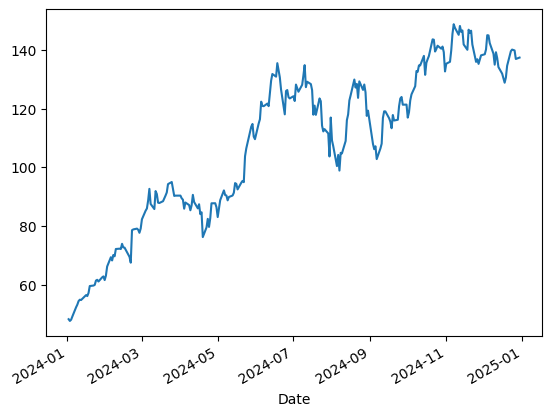

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

def price_series(ticker):
    # takes a ticker. gets the period's closing price series. squeezes it. graphs using pandas series.plot()

    price = yf.download(ticker, start='2024-01-01', end='2024-12-31', auto_adjust=False)

    price = price['Close'].squeeze()

    price.plot()

    return

price_series('NVDA')

price = yf.download('NVDA', start='2024-06-01', end='2024-06-30', auto_adjust=False)['Close'].squeeze()
print(price)

conclusion: yfin is auto-adjusting anyway; always check data source and what is happening!

matplotlib plots r cool


let's do cleaner functions

In [ ]:
def return_series(ticker, period='1y', start=None, end=None):
    # takes a ticker. gets the period's closing price series. squeezes it. gets return


    if start != None:
        price = yf.download(ticker, start=start, end=end, auto_adjust=True)
    else:
        price = yf.download(ticker, period=period, interval='1d', auto_adjust=True)


    price = price['Close'].squeeze()

    price_A = price[1:].values[:]
    price_B = price[:-1].values[:]

    return (price_A - price_B) / price_B

redo sharpe, using this function:

In [ ]:
def sharpe(ticker, period='1y', start=None, end=None):
    ret = return_series(ticker, period, start, end)

    risk_free = (yf.Ticker('^IRX').info['previousClose']) / 100

    return ((ret.mean() * 252) - risk_free) / ((ret.std()) * np.sqrt(252))